# Download Integration

This notebook demonstrates the **Download** stage of the Foreign Whispers dubbing pipeline.
It downloads a YouTube video and its closed captions via `yt-dlp` through the FastAPI backend.

**Prerequisites:**
- The Docker stack must be running (`docker compose --profile nvidia up -d`).
- The API should be accessible at `http://localhost:8080`.

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

# Load .env (LOGFIRE_TOKEN, HF_TOKEN, etc.)
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

# Optional: Logfire tracing (no-op shim if unavailable)
try:
    import logfire
    logfire.configure(service_name="foreign-whispers-download")
    print("Logfire tracing enabled.")
except Exception:
    class _NoopSpan:
        def __enter__(self): return self
        def __exit__(self, *a): pass
    class _noop:
        @staticmethod
        def span(name, **kw): return _NoopSpan()
        @staticmethod
        def info(*a, **kw): pass
    logfire = _noop()
    print("Logfire not configured — using no-op shim.")

Project root: /Users/adit/Documents/Coding/AIAssignments/AiProject/foreign-whispers
Logfire not configured — using no-op shim.


In [3]:
from foreign_whispers.client import FWClient

fw = FWClient("http://localhost:8080")
fw.healthz()

ConnectionError: HTTPConnectionPool(host='localhost', port=8080): Max retries exceeded with url: /healthz (Caused by NewConnectionError("HTTPConnection(host='localhost', port=8080): Failed to establish a new connection: [Errno 61] Connection refused"))

## Download Video and Captions

The API wraps `yt-dlp` to download the video MP4 and extract any available closed captions.
The `fw.download()` call returns a dict with `video_id`, `title`, and `caption_segments`.

In [4]:
VIDEO_URL = "https://www.youtube.com/watch?v=GYQ5yGV_-Oc"

with logfire.span("download", video_url=VIDEO_URL):
    dl = fw.download(VIDEO_URL)

print(f"Video ID:       {dl['video_id']}")
print(f"Title:          {dl['title']}")
print(f"Caption count:  {len(dl['caption_segments'])}")
print()
print("First 5 caption segments:")
for seg in dl["caption_segments"][:5]:
    dur = seg.get("duration", 0)
    print(f"  [{seg['start']:.2f}s, {dur:.2f}s] {seg['text']}")

ConnectionError: HTTPConnectionPool(host='localhost', port=8080): Max retries exceeded with url: /api/download (Caused by NewConnectionError("HTTPConnection(host='localhost', port=8080): Failed to establish a new connection: [Errno 61] Connection refused"))

In [5]:
import yt_dlp
from pathlib import Path

VIDEO_URL = "https://www.youtube.com/watch?v=GYQ5yGV_-Oc"

data_dir = PROJECT_ROOT / "pipeline_data" / "api"
videos_dir = data_dir / "videos"
captions_dir = data_dir / "youtube_captions"
videos_dir.mkdir(parents=True, exist_ok=True)
captions_dir.mkdir(parents=True, exist_ok=True)

ydl_opts = {
    "format": "mp4",
    "outtmpl": str(videos_dir / "%(id)s.%(ext)s"),
    "writesubtitles": True,
    "writeautomaticsub": True,
    "subtitleslangs": ["en"],
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(VIDEO_URL, download=True)

video_id = info["id"]
print(f"Video ID: {video_id}")
print(f"Title:    {info['title']}")

[youtube] Extracting URL: https://www.youtube.com/watch?v=GYQ5yGV_-Oc
[youtube] GYQ5yGV_-Oc: Downloading webpage


[youtube] GYQ5yGV_-Oc: Downloading android vr player API JSON
[info] GYQ5yGV_-Oc: Downloading subtitles: en
[info] GYQ5yGV_-Oc: Downloading 1 format(s): 18
[info] Writing video subtitles to: /Users/adit/Documents/Coding/AIAssignments/AiProject/foreign-whispers/pipeline_data/api/videos/GYQ5yGV_-Oc.en.vtt


[download] Destination: /Users/adit/Documents/Coding/AIAssignments/AiProject/foreign-whispers/pipeline_data/api/videos/GYQ5yGV_-Oc.en.vtt
[download] 100% of   55.48KiB in 00:00:00 at 785.56KiB/s
[download] Destination: /Users/adit/Documents/Coding/AIAssignments/AiProject/foreign-whispers/pipeline_data/api/videos/GYQ5yGV_-Oc.mp4
[download] 100% of   19.17MiB in 00:00:01 at 16.27MiB/s  
Video ID: GYQ5yGV_-Oc
Title:    Strait of Hormuz disruption threatens to shake global economy


In [8]:
import re
import json
import shutil

# Move the VTT file to the captions directory
vtt_src = videos_dir / f"{video_id}.en.vtt"
vtt_dst = captions_dir / f"{video_id}.en.vtt"
shutil.move(str(vtt_src), str(vtt_dst))

# Parse VTT into segments
def parse_vtt(vtt_path):
    text = Path(vtt_path).read_text()
    segments = []
    blocks = re.split(r"\n\n+", text.strip())
    for block in blocks:
        lines = block.strip().splitlines()
        # Find the timecode line
        time_line = next((l for l in lines if "-->" in l), None)
        if not time_line:
            continue
        def to_seconds(t):
            t = t.strip().split(".")[0]
            parts = t.split(":")
            return sum(float(x) * 60**i for i, x in enumerate(reversed(parts)))
        start_str, end_str = time_line.split("-->")
        start = to_seconds(start_str)
        end = to_seconds(end_str)
        text_lines = [l for l in lines if "-->" not in l and not l.strip().isdigit()]
        text = " ".join(text_lines).strip()
        if text:
            segments.append({"start": start, "end": end, "duration": end - start, "text": text})
    return segments

caption_segments = parse_vtt(vtt_dst)

# Save as JSON
json_path = captions_dir / f"{video_id}.json"
json_path.write_text(json.dumps(caption_segments, indent=2))

print(f"Parsed {len(caption_segments)} caption segments")
for seg in caption_segments[:5]:
    print(f"  [{seg['start']:.2f}s – {seg['end']:.2f}s] {seg['text']}")

Parsed 338 caption segments
  [2.00s – 6.00s] 60<00:00:02.720><c> Minutes</c><00:00:03.120><c> overtime.</c>
  [6.00s – 7.00s] What's<00:00:06.720><c> the</c><00:00:06.879><c> worst</c><00:00:07.200><c> case</c><00:00:07.359><c> scenario</c><00:00:07.759><c> that</c>
  [7.00s – 8.00s] What's the worst case scenario that
  [8.00s – 10.00s] What's the worst case scenario that you're<00:00:08.240><c> worried</c><00:00:08.480><c> about</c><00:00:09.360><c> is</c><00:00:09.599><c> that</c><00:00:09.760><c> it</c><00:00:10.000><c> is</c>
  [10.00s – 10.00s] you're worried about is that it is


## Inspect Downloaded Artifacts

The download stage writes files into the `pipeline_data/api/` directory tree:

- `pipeline_data/api/videos/` — source MP4 files
- `pipeline_data/api/youtube_captions/` — extracted caption JSON files

In [9]:
videos_dir = PROJECT_ROOT / "pipeline_data" / "api" / "videos"
captions_dir = PROJECT_ROOT / "pipeline_data" / "api" / "youtube_captions"

print("Videos:")
for f in sorted(videos_dir.iterdir()):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name}  ({size_mb:.1f} MB)")

print()
print("YouTube captions:")
for f in sorted(captions_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:.1f} KB)")

Videos:
  GYQ5yGV_-Oc.mp4  (19.2 MB)

YouTube captions:
  GYQ5yGV_-Oc.en.vtt  (55.5 KB)
  GYQ5yGV_-Oc.json  (63.8 KB)


## Visualize Caption Timeline

Plot the downloaded caption segments as horizontal bars on a timeline to visualize
their temporal distribution across the video.

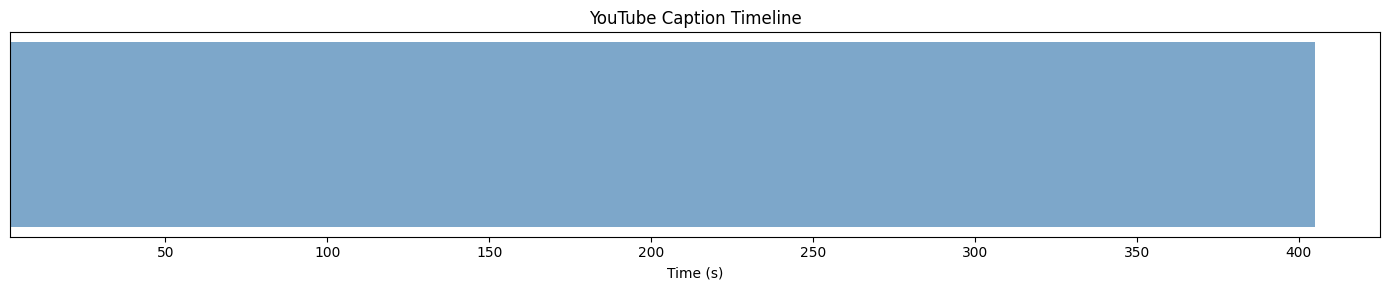

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 3))
for seg in caption_segments:
    dur = seg.get("duration", 0)
    if dur > 0:
        ax.barh(0, dur, left=seg["start"], height=0.5, color="steelblue", alpha=0.7)
ax.set_xlabel("Time (s)")
ax.set_title("YouTube Caption Timeline")
ax.set_yticks([])
fig.tight_layout()
fig.savefig(str(IMAGES_DIR / "caption_timeline.png"), dpi=150)
plt.show()

## Summary

The download stage produced:

- **MP4 video file** in `pipeline_data/api/videos/`
- **YouTube captions JSON** in `pipeline_data/api/youtube_captions/`

These artifacts are consumed by the next pipeline stages (transcription, translation, TTS, and stitching).